,Annee,Prediction_Pauvrete,Milieu
0,2025,2.663510,Milieu Urbain
1,2026,2.540120,Milieu Urbain
2,2027,2.416731,Milieu Urbain
3,2028,2.293341,Milieu Urbain
4,2029,2.169951,Milieu Urbain
5,2030,2.046561,Milieu Urbain
6,2025,9.090486,Milieu Rural
7,2026,7.906003,Milieu Rural
8,2027,6.721520,Milieu Rural
9,2028,5.537036,Milieu Rural


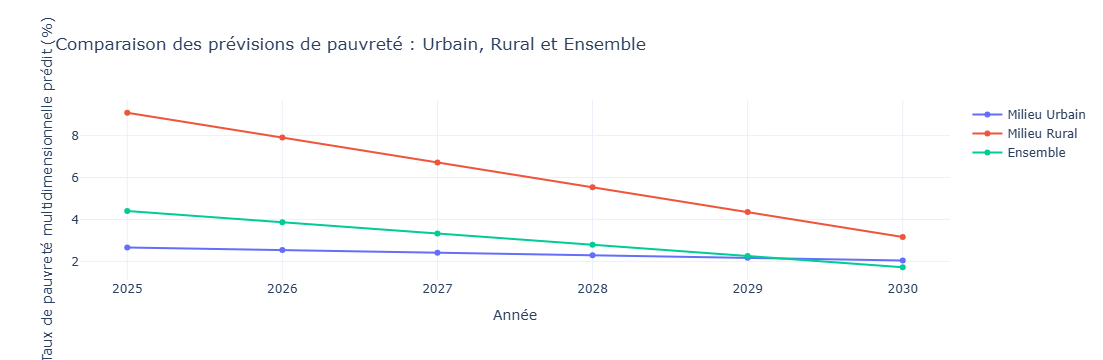

ANALYSE DES PRÉVISIONS DE LA PAUVRETÉ

Milieu Urbain
Le taux de pauvreté multidimensionnelle prédit passe de 2.66% en 2025 à 2.05% en 2030.
La tendance prévue indique une diminution de la pauvreté.

Milieu Rural
Le taux de pauvreté multidimensionnelle prédit passe de 9.09% en 2025 à 3.17% en 2030.
La tendance prévue indique une diminution de la pauvreté.

Ensemble
Le taux de pauvreté multidimensionnelle prédit passe de 4.41% en 2025 à 1.72% en 2030.
La tendance prévue indique une diminution de la pauvreté.


In [2]:
# =========================================================
# Prévision de la pauvreté : Urbain / Rural / Ensemble
# Avec Machine Learning + Matplotlib
# Accuracy - Precision - Recall
# =========================================================

# =========================================================
# Prévision de la pauvreté : Urbain / Rural / Ensemble
# Avec Machine Learning + Plotly
# =========================================================

import pandas as pd
import numpy as np
import plotly.graph_objects as go

from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score


# =========================================================
# 1. Charger les fichiers CSV
# =========================================================

urbain = pd.read_csv(r"../data/Urbain.csv")
rural = pd.read_csv(r"../data/Rural.csv")
ensemble = pd.read_csv(r"../data/Ensemble.csv")


# =========================================================
# 2. Nettoyage des données
# =========================================================

def nettoyer_donnees(df):
    data = df[df["col_4"].isin(["2014", "2024", 2014, 2024])].copy()

    data = data.rename(columns={
        "col_4": "Annee",
        "col_6": "Pauvrete"
    })

    data["Annee"] = pd.to_numeric(data["Annee"], errors="coerce")
    data["Pauvrete"] = pd.to_numeric(data["Pauvrete"], errors="coerce")

    data = data.dropna(subset=["Annee", "Pauvrete"])

    return data[["Annee", "Pauvrete"]]





# =========================================================
# 5. Fusion des résultats
# =========================================================

resultats_prediction = pd.concat(
    [pred_urbain, pred_rural, pred_ensemble],
    ignore_index=True
)

display(resultats_prediction)


# =========================================================
# 6. Graphique comparatif final
# =========================================================

fig_comparaison = go.Figure()

for milieu in resultats_prediction["Milieu"].unique():
    data_milieu = resultats_prediction[
        resultats_prediction["Milieu"] == milieu
    ]

    fig_comparaison.add_trace(go.Scatter(
        x=data_milieu["Annee"],
        y=data_milieu["Prediction_Pauvrete"],
        mode="lines+markers",
        name=milieu
    ))

fig_comparaison.update_layout(
    title="Comparaison des prévisions de pauvreté : Urbain, Rural et Ensemble",
    xaxis_title="Année",
    yaxis_title="Taux de pauvreté multidimensionnelle prédit (%)",
    template="plotly_white",
    hovermode="x unified"
)

fig_comparaison.show()


# =========================================================
# 7. Analyse automatique en français
# =========================================================

print("====================================================")
print("ANALYSE DES PRÉVISIONS DE LA PAUVRETÉ")
print("====================================================")

for milieu in resultats_prediction["Milieu"].unique():
    df_milieu = resultats_prediction[resultats_prediction["Milieu"] == milieu]

    valeur_2025 = df_milieu[df_milieu["Annee"] == 2025]["Prediction_Pauvrete"].values[0]
    valeur_2030 = df_milieu[df_milieu["Annee"] == 2030]["Prediction_Pauvrete"].values[0]

    evolution = valeur_2030 - valeur_2025

    print(f"\n{milieu}")
    print(
        f"Le taux de pauvreté multidimensionnelle prédit passe de "
        f"{valeur_2025:.2f}% en 2025 à {valeur_2030:.2f}% en 2030."
    )

    if evolution < 0:
        print("La tendance prévue indique une diminution de la pauvreté.")
    elif evolution > 0:
        print("La tendance prévue indique une augmentation de la pauvreté.")
    else:
        print("La tendance prévue reste stable.")